### FED COMPARISON

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
import matplotlib.patches as mpatches
import matplotlib as mpl
from scipy.stats import wilcoxon, mannwhitneyu


# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

os.makedirs('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison', exist_ok=True)


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df1['role'] = df1['track_id'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'fed']
df1['condition'] = 'fed(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/head_head_contacts_kinematics_over_time_nocontacts_ref-window10.csv')
df2['condition'] = 'fed(f-f)'

df = pd.concat([df1, df2], ignore_index=True)



df['interaction_group'] = np.select(
    [
        (df['interaction_number'] == 1) & (df['interaction_frame'] < 1200),
        (df['interaction_number'] == 1) & (df['interaction_frame'] >= 1200),
    ],
    [
        'first',
        'not_viable_first',
    ],
    default='other'
)
df = df[df['interaction_group'] != 'not_viable_first'].copy()


df = df.sort_values(['condition', 'file', 'track_id', 'rel_frame'])


metrics = ['speed_head', 'speed_body', 'speed_tail', 'heading_angle', 'heading_angle_change', 'approach_angle', 'approach_angle_head', 'cum_distance_start', 'cum_distance_0', 'distance_from_0', 'directional_alignment_cosine', 'track0_projection_onto_track1', 'head_distance']

file_larva_timecourse = (
    df.groupby(['condition', 'file', 'track_id', 'interaction_group', 'rel_frame'])[metrics]
      .mean()
      .reset_index()
)

first_interaction = file_larva_timecourse[file_larva_timecourse['interaction_group'] == 'first']

# Average larvae within each file before stats, so each recording contributes once.
first_interaction_file = (
    first_interaction
    .groupby(['condition', 'file', 'interaction_group', 'rel_frame'])[metrics]
    .mean()
    .reset_index()
)


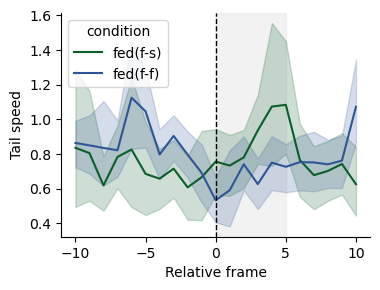

In [19]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='speed_tail',
    hue='condition',
    hue_order=['fed(f-s)', 'fed(f-f)'],
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvspan(0, 5, color='0.9', alpha=0.5, zorder=0)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('Tail speed')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/speed.pdf', format='pdf')
plt.show()


In [15]:
# Frames 1-5: average tail speed per file, then independent fed(f-s) vs fed(f-f) test
speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_5)
print(speed_1_5.mean())

stat, p = mannwhitneyu(speed_1_5['fed(f-s)'].dropna(), speed_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-5, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-24-02_td14.tracks.feather,NaN,1.525206
2026-04-28_12-25-04_td15.tracks.feather,NaN,0.495252
2026-04-28_12-26-23_td16.tracks.feather,NaN,0.858436
2026-04-28_12-27-50_td17.tracks.feather,NaN,1.121139
2026-04-28_15-17-04_td10.tracks.feather,1.064252,NaN
2026-04-28_15-18-47_td11.tracks.feather,0.612085,NaN
2026-05-12_14-51-49_td19.tracks.feather,0.455618,NaN
2026-05-12_14-59-35_td16.tracks.feather,NaN,0.600464
2026-05-12_15-00-30_td15.tracks.feather,NaN,1.221485


condition
fed(f-f)    0.687657
fed(f-s)    0.921975
dtype: float64
Mann-Whitney U test, frames 1-5, fed(f-s) vs fed(f-f): U=105, p=0.132


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/1720135754.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


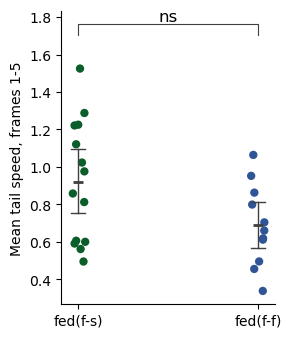

In [5]:
# Plot the values used in the frames 1-5 speed test
speed_1_5_plot = speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='speed_tail'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=speed_1_5_plot,
    x='condition',
    y='speed_tail',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = speed_1_5_plot['speed_tail'].max()
ymin = speed_1_5_plot['speed_tail'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean tail speed, frames 1-5')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/speed_mean.pdf', format='pdf')
plt.show()


In [6]:
# Frames 1-5 after contact compared with frames -5 to -1 before contact, tail speed
pre_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(-5, -1)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

post_speed_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

change_speed_1_5 = post_speed_1_5 - pre_speed_1_5

display(pd.concat({'pre': pre_speed_1_5, 'post': post_speed_1_5, 'post_minus_pre': change_speed_1_5}, axis=1))
print('Mean pre:')
print(pre_speed_1_5.mean())
print('\nMean post:')
print(post_speed_1_5.mean())
print('\nMean post - pre:')
print(change_speed_1_5.mean())

fed_fs_pairs = pd.concat([pre_speed_1_5['fed(f-s)'], post_speed_1_5['fed(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fs = wilcoxon(fed_fs_pairs['pre'], fed_fs_pairs['post'])
print(f"fed(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fs:.3g}")

fed_ff_pairs = pd.concat([pre_speed_1_5['fed(f-f)'], post_speed_1_5['fed(f-f)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_ff = wilcoxon(fed_ff_pairs['pre'], fed_ff_pairs['post'])
print(f"fed(f-f) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_ff:.3g}")

stat, change_p = mannwhitneyu(change_speed_1_5['fed(f-s)'].dropna(), change_speed_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Change score, tail speed fed(f-s) vs fed(f-f), frames 1-5: U={stat:.3g}, p={change_p:.3g}")


pre                post  \
condition                                fed(f-f)  fed(f-s)  fed(f-f)   
file                                                                    
2026-04-28_12-24-02_td14.tracks.feather       NaN  0.486570       NaN   
2026-04-28_12-25-04_td15.tracks.feather       NaN  0.401260       NaN   
2026-04-28_12-26-23_td16.tracks.feather       NaN  0.492318       NaN   
2026-04-28_12-27-50_td17.tracks.feather       NaN  0.983625       NaN   
2026-04-28_15-17-04_td10.tracks.feather  1.105869       NaN  1.064252   
2026-04-28_15-18-47_td11.tracks.feather  0.874476       NaN  0.612085   
2026-05-12_14-51-49_td19.tracks.feather  0.782263       NaN  0.455618   
2026-05-12_14-59-35_td16.tracks.feather       NaN  0.502045       NaN   
2026-05-12_15-00-30_td15.tracks.feather       NaN  0.633517       NaN   
2026-05-18_12-02-50_td17.tracks.feather  0.889437       NaN  0.618715   
2026-05-18_12-06-01_td19.tracks.feather  1.044948       NaN  0.704319   
2026-05-18_12-10-36_td16.tracks.feather       NaN  1.177633       NaN   
2026-05-18_15-15-17_td1.tracks.feather   1.142123       NaN  0.495723   
2026-05-18_15-18-00_td2.tracks.feather   1.071161       NaN  0.862987   
2026-05-18_15-20-40_td5.tracks.feather   0.562789       NaN  0.660478   
2026-05-18_15-25-18_td9.tracks.feather        NaN  1.289985       NaN   
2026-06-05_12-11-35_td17.tracks.feather  0.794429       NaN  0.799302   
2026-06-05_12-13-24_td16.tracks.feather  0.774814       NaN  0.952487   
2026-06-05_12-18-12_td18.tracks.feather       NaN  0.966561       NaN   
2026-06-05_12-19-26_td19.tracks.feather       NaN  0.555894       NaN   
2026-06-05_12-20-32_td20.tracks.feather       NaN  0.435258       NaN   
2026-06-22_12-08-50_td14.tracks.feather  0.281773       NaN  0.338258   
2026-06-22_12-13-15_td16.tracks.feather       NaN  0.714328       NaN   
2026-06-22_12-14-29_td17.tracks.feather       NaN  0.130478       NaN   
2026-06-23_16-02-35_td17.tracks.feather       NaN  0.571404       NaN   

                                                  post_minus_pre            
condition                                fed(f-s)       fed(f-f)  fed(f-s)  
file                                                                        
2026-04-28_12-24-02_td14.tracks.feather  1.525206            NaN  1.038636  
2026-04-28_12-25-04_td15.tracks.feather  0.495252            NaN  0.093992  
2026-04-28_12-26-23_td16.tracks.feather  0.858436            NaN  0.366118  
2026-04-28_12-27-50_td17.tracks.feather  1.121139            NaN  0.137514  
2026-04-28_15-17-04_td10.tracks.feather       NaN      -0.041616       NaN  
2026-04-28_15-18-47_td11.tracks.feather       NaN      -0.262391       NaN  
2026-05-12_14-51-49_td19.tracks.feather       NaN      -0.326645       NaN  
2026-05-12_14-59-35_td16.tracks.feather  0.600464            NaN  0.098418  
2026-05-12_15-00-30_td15.tracks.feather  1.221485            NaN  0.587968  
2026-05-18_12-02-50_td17.tracks.feather       NaN      -0.270722       NaN  
2026-05-18_12-06-01_td19.tracks.feather       NaN      -0.340629       NaN  
2026-05-18_12-10-36_td16.tracks.feather  1.225547            NaN  0.047914  
2026-05-18_15-15-17_td1.tracks.feather        NaN      -0.646399       NaN  
2026-05-18_15-18-00_td2.tracks.feather        NaN      -0.208174       NaN  
2026-05-18_15-20-40_td5.tracks.feather        NaN       0.097689       NaN  
2026-05-18_15-25-18_td9.tracks.feather   1.288038            NaN -0.001947  
2026-06-05_12-11-35_td17.tracks.feather       NaN       0.004873       NaN  
2026-06-05_12-13-24_td16.tracks.feather       NaN       0.177673       NaN  
2026-06-05_12-18-12_td18.tracks.feather  0.561907            NaN -0.404654  
2026-06-05_12-19-26_td19.tracks.feather  0.606293            NaN  0.050399  
2026-06-05_12-20-32_td20.tracks.feather  0.591277            NaN  0.156019  
2026-06-22_12-08-50_td14.tracks.feather       NaN       0.056484       NaN  
2026-06-22_12-13-15_td16.tracks.feather  0.812628            NaN  0.098300  

Mean pre:
condition
fed(f-f)    0.847644
fed(f-s)    0.667205
dtype: float64

Mean post:
condition
fed(f-f)    0.687657
fed(f-s)    0.921975
dtype: float64

Mean post - pre:
condition
fed(f-f)   -0.159987
fed(f-s)    0.254770
dtype: float64
fed(f-s) pre vs post, tail speed frames 1-5: W=11, p=0.00671
fed(f-f) pre vs post, tail speed frames 1-5: W=13, p=0.083
Change score, tail speed fed(f-s) vs fed(f-f), frames 1-5: U=128, p=0.0057


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/371239158.py:33: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


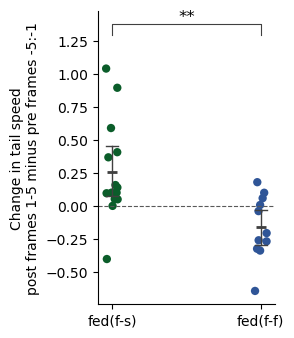

In [7]:
# Plot the values used in the frames 1-5 speed change-score test
change_speed_1_5_plot = change_speed_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='speed_change'
)

if change_p < 0.001:
    stars = '***'
elif change_p < 0.01:
    stars = '**'
elif change_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=change_speed_1_5_plot,
    x='condition',
    y='speed_change',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

plt.axhline(0, color='0.35', linewidth=0.8, linestyle='--')

ymax = change_speed_1_5_plot['speed_change'].max()
ymin = change_speed_1_5_plot['speed_change'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Change in tail speed\npost frames 1-5 minus pre frames -5:-1')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/speed_baseline_change.pdf', format='pdf')
plt.show()


In [8]:
# Test whether each condition changes from before to after contact, frames 1-5
fed_fs_pairs = pd.concat([pre_speed_1_5['fed(f-s)'], post_speed_1_5['fed(f-s)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_fs = wilcoxon(fed_fs_pairs['pre'], fed_fs_pairs['post'])
print(f"fed(f-s) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_fs:.3g}")
print(f"fed(f-s) mean change: {change_speed_1_5['fed(f-s)'].mean():.3g}")

fed_ff_pairs = pd.concat([pre_speed_1_5['fed(f-f)'], post_speed_1_5['fed(f-f)']], axis=1, keys=['pre', 'post']).dropna()
stat, p_fed_ff = wilcoxon(fed_ff_pairs['pre'], fed_ff_pairs['post'])
print(f"fed(f-f) pre vs post, tail speed frames 1-5: W={stat:.3g}, p={p_fed_ff:.3g}")
print(f"fed(f-f) mean change: {change_speed_1_5['fed(f-f)'].mean():.3g}")


fed(f-s) pre vs post, tail speed frames 1-5: W=11, p=0.00671
fed(f-s) mean change: 0.255
fed(f-f) pre vs post, tail speed frames 1-5: W=13, p=0.083
fed(f-f) mean change: -0.16


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/2989756133.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/2989756133.py:46: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


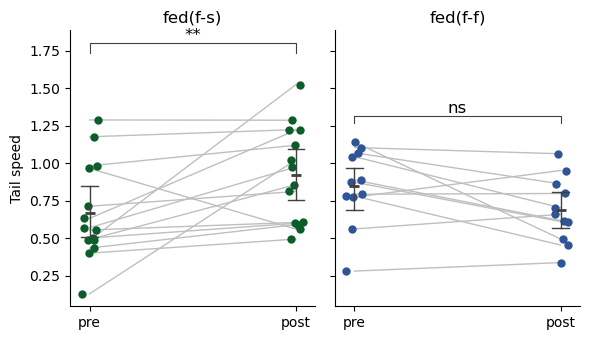

In [9]:
# Plot pre vs post tail speed within each condition, frames 1-5
fig, axes = plt.subplots(1, 2, figsize=(6, 3.5), sharey=True)

for ax, condition, color, test_p in zip(
    axes,
    ['fed(f-s)', 'fed(f-f)'],
    ['#0B5D2A', '#2F5597'],
    [p_fed_fs, p_fed_ff]
):
    plot_data = pd.DataFrame({
        'file': pre_speed_1_5.index,
        'pre': pre_speed_1_5[condition],
        'post': post_speed_1_5[condition]
    }).dropna()
    long_plot_data = plot_data.melt(
        id_vars='file',
        value_vars=['pre', 'post'],
        var_name='time',
        value_name='speed_tail'
    )

    if test_p < 0.001:
        stars = '***'
    elif test_p < 0.01:
        stars = '**'
    elif test_p < 0.05:
        stars = '*'
    else:
        stars = 'ns'

    for _, row in plot_data.iterrows():
        ax.plot([0, 1], [row['pre'], row['post']], color='0.75', linewidth=1, zorder=1)

    sns.stripplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        color=color,
        size=6,
        jitter=0.04,
        ax=ax,
        zorder=2
    )

    sns.pointplot(
        data=long_plot_data,
        x='time',
        y='speed_tail',
        order=['pre', 'post'],
        errorbar=('ci', 95),
        color='0.25',
        markers='_',
        linestyles='none',
        capsize=0.08,
        err_kws={'linewidth': 1},
        join=False,
        ax=ax
    )

    ymax = long_plot_data['speed_tail'].max()
    ymin = long_plot_data['speed_tail'].min()
    y_range = ymax - ymin if ymax > ymin else 1
    y = ymax + y_range * 0.15
    h = y_range * 0.05
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
    ax.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

    ax.set_title(condition)
    ax.set_xlabel('')
    ax.set_ylabel('Tail speed' if condition == 'fed(f-s)' else '')

sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/speed_baseline_change_within_condition.pdf', format='pdf')
plt.show()


In [10]:
# Frames 1-10: average tail speed per file, then independent fed(f-s) vs fed(f-f) test
speed_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['speed_tail']
    .mean()
    .unstack()
)

display(speed_1_10)
print(speed_1_10.mean())

stat, p = mannwhitneyu(speed_1_10['fed(f-s)'].dropna(), speed_1_10['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, frames 1-10, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-24-02_td14.tracks.feather,NaN,1.073169
2026-04-28_12-25-04_td15.tracks.feather,NaN,0.413210
2026-04-28_12-26-23_td16.tracks.feather,NaN,0.863178
2026-04-28_12-27-50_td17.tracks.feather,NaN,0.979272
2026-04-28_15-17-04_td10.tracks.feather,1.081082,NaN
2026-04-28_15-18-47_td11.tracks.feather,0.625894,NaN
2026-05-12_14-51-49_td19.tracks.feather,0.557356,NaN
2026-05-12_14-59-35_td16.tracks.feather,NaN,0.591138
2026-05-12_15-00-30_td15.tracks.feather,NaN,1.139358


condition
fed(f-f)    0.752116
fed(f-s)    0.812703
dtype: float64
Mann-Whitney U test, frames 1-10, fed(f-s) vs fed(f-f): U=85, p=0.681


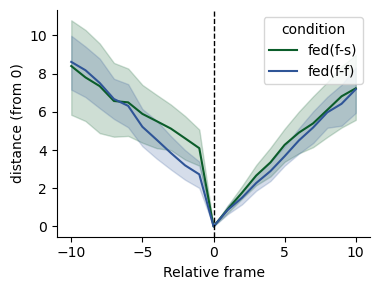

In [11]:
plt.figure(figsize=(3.9, 3))

sns.lineplot(
    data=first_interaction,
    x='rel_frame',
    y='distance_from_0',
    hue='condition',
    hue_order=['fed(f-s)', 'fed(f-f)'],
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar=('ci', 95)
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Relative frame')
plt.ylabel('distance (from 0)')
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/distance_from_0.pdf', format='pdf')
plt.show()


In [12]:
# Frames 1-5: average distance_from_0 per file, then independent fed(f-s) vs fed(f-f) test
distance_1_5 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 5)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_5)
print(distance_1_5.mean())

stat, p = mannwhitneyu(distance_1_5['fed(f-s)'].dropna(), distance_1_5['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-5, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-24-02_td14.tracks.feather,NaN,1.877705
2026-04-28_12-25-04_td15.tracks.feather,NaN,1.524979
2026-04-28_12-26-23_td16.tracks.feather,NaN,2.707751
2026-04-28_12-27-50_td17.tracks.feather,NaN,3.750333
2026-04-28_15-17-04_td10.tracks.feather,3.173181,NaN
2026-04-28_15-18-47_td11.tracks.feather,1.430154,NaN
2026-05-12_14-51-49_td19.tracks.feather,2.160087,NaN
2026-05-12_14-59-35_td16.tracks.feather,NaN,1.717969
2026-05-12_15-00-30_td15.tracks.feather,NaN,3.490859


condition
fed(f-f)    2.241261
fed(f-s)    2.590244
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-5, fed(f-s) vs fed(f-f): U=93, p=0.396


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/2166148900.py:35: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


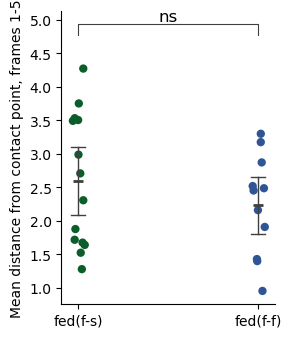

In [13]:
# Plot the values used in the frames 1-5 distance_from_0 test
_, distance_p = mannwhitneyu(distance_1_5['fed(f-s)'].dropna(), distance_1_5['fed(f-f)'].dropna(), alternative='two-sided')

distance_1_5_plot = distance_1_5.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='distance_from_0'
)

if distance_p < 0.001:
    stars = '***'
elif distance_p < 0.01:
    stars = '**'
elif distance_p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_5_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_5_plot['distance_from_0'].max()
ymin = distance_1_5_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-5')
sns.despine()
plt.tight_layout()
plt.show()


condition,fed(f-f),fed(f-s)
file,,
2026-04-28_12-24-02_td14.tracks.feather,NaN,3.510850
2026-04-28_12-25-04_td15.tracks.feather,NaN,2.407758
2026-04-28_12-26-23_td16.tracks.feather,NaN,4.879938
2026-04-28_12-27-50_td17.tracks.feather,NaN,5.827089
2026-04-28_15-17-04_td10.tracks.feather,5.057109,NaN
2026-04-28_15-18-47_td11.tracks.feather,2.805352,NaN
2026-05-12_14-51-49_td19.tracks.feather,3.443695,NaN
2026-05-12_14-59-35_td16.tracks.feather,NaN,3.130965
2026-05-12_15-00-30_td15.tracks.feather,NaN,6.354801


condition
fed(f-f)    4.046322
fed(f-s)    4.340504
dtype: float64
Mann-Whitney U test, distance_from_0 frames 1-10, fed(f-s) vs fed(f-f): U=81, p=0.848


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/4020496783.py:47: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


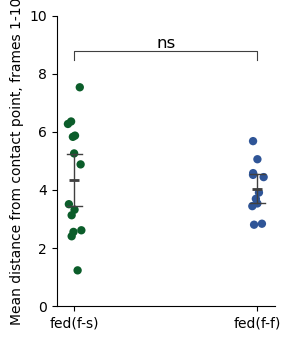

In [14]:
# Frames 1-10: average distance_from_0 per file, then independent fed(f-s) vs fed(f-f) test
distance_1_10 = (
    first_interaction_file[first_interaction_file['rel_frame'].between(1, 10)]
    .groupby(['file', 'condition'])['distance_from_0']
    .mean()
    .unstack()
)

display(distance_1_10)
print(distance_1_10.mean())

stat, p = mannwhitneyu(distance_1_10['fed(f-s)'].dropna(), distance_1_10['fed(f-f)'].dropna(), alternative='two-sided')
print(f"Mann-Whitney U test, distance_from_0 frames 1-10, fed(f-s) vs fed(f-f): U={stat:.3g}, p={p:.3g}")

# Plot the values used in the frames 1-10 distance_from_0 test
distance_1_10_plot = distance_1_10.reset_index().melt(
    id_vars='file',
    value_vars=['fed(f-s)', 'fed(f-f)'],
    var_name='condition',
    value_name='distance_from_0'
)

if p < 0.001:
    stars = '***'
elif p < 0.01:
    stars = '**'
elif p < 0.05:
    stars = '*'
else:
    stars = 'ns'

plt.figure(figsize=(3, 3.5))

sns.stripplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    hue='condition',
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    size=6,
    jitter=0.04,
    legend=False,
    zorder=2
)

sns.pointplot(
    data=distance_1_10_plot,
    x='condition',
    y='distance_from_0',
    order=['fed(f-s)', 'fed(f-f)'],
    errorbar=('ci', 95),
    color='0.25',
    markers='_',
    linestyles='none',
    capsize=0.08,
    err_kws={'linewidth': 1},
    join=False
)

ymax = distance_1_10_plot['distance_from_0'].max()
ymin = distance_1_10_plot['distance_from_0'].min()
y_range = ymax - ymin if ymax > ymin else 1
y = ymax + y_range * 0.15
h = y_range * 0.05
plt.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='0.25', linewidth=0.8)
plt.text(0.5, y + h, stars, ha='center', va='bottom', fontsize=12)

plt.xlabel('')
plt.ylabel('Mean distance from contact point, frames 1-10')
plt.ylim(0, 10)
sns.despine()
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/distance_from_0_mean.pdf', format='pdf')
plt.show()


In [16]:


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-starved/speed_over_time.csv')
df1['role'] = df1['track'].map({0: 'starved', 1: 'fed'})
df1 = df1[df1['role'] == 'fed']
df1['condition'] = 'fed(f-s)'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/group-housed/fed-fed/speed_over_time.csv')
df2['condition'] = 'fed(f-f)'

df = pd.concat([df1, df2], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_32817/3369614135.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


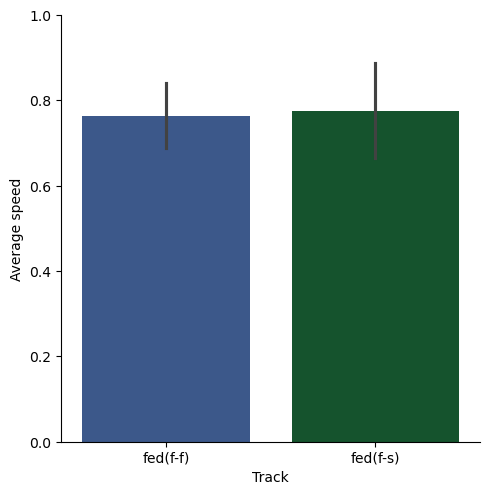

Track fed(f-f) vs track fed(f-s)
Mann-Whitney U = 334
p = 0.6096


In [18]:
speed_summary = (
    df
    .groupby(['file', 'condition'], as_index=False)['speed']
    .mean()
)

track_order = sorted(speed_summary['condition'].dropna().unique())

fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=speed_summary,
    x='condition',
    y='speed',
    order=track_order,
    palette={'fed(f-s)': '#0B5D2A', 'fed(f-f)': '#2F5597'},
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Track')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/gh/fed-comparison/avg_speed.pdf', format='pdf')
plt.show()




track_0 = speed_summary.loc[speed_summary['condition'] == track_order[0], 'speed'].dropna()
track_1 = speed_summary.loc[speed_summary['condition'] == track_order[1], 'speed'].dropna()

test = mannwhitneyu(track_0, track_1, alternative='two-sided')

print(f'Track {track_order[0]} vs track {track_order[1]}')
print(f'Mann-Whitney U = {test.statistic:.4g}')
print(f'p = {test.pvalue:.4g}')